## Model 3 Neural Network



## 1 - Packages
Firstly import all the needed packages, these are taken from the lab on NN

In [36]:
import ipympl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import *
from utils import load_split, FEATURE_COLUMNS
from pathlib import Path
from sklearn.metrics import classification_report
import pandas as pd


%matplotlib inline

plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from autils import *
from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

## 2 - Loading data

In [37]:
DATA_DIR   = Path("data/processed")

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print ('The shape of X is: ' + str(X_train.shape))
print ('The shape of y is: ' + str(y_train.shape))

The shape of X is: (100778, 41)
The shape of y is: (100778,)


## 3 - Training model 3.1: Neural network with 20 training cycles and no regularisation 

In [50]:
input_shape = (X_train.shape[1],) 
num_classes = 40
print("--- Building Model 2 ---")
# Build Model 1 (Neural network with 20 training cycles, no early stopping)
model_3_1 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=input_shape),
    layers.Dropout(0.3), 
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model_3_1.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

# Train
history_1 = model_3_1.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)

--- Building Model 2 ---
Epoch 1/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9517 - loss: 0.2016 - val_accuracy: 0.9886 - val_loss: 0.0474
Epoch 2/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9828 - loss: 0.0640 - val_accuracy: 0.9892 - val_loss: 0.0359
Epoch 3/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9864 - loss: 0.0522 - val_accuracy: 0.9910 - val_loss: 0.0316
Epoch 4/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9879 - loss: 0.0432 - val_accuracy: 0.9910 - val_loss: 0.0310
Epoch 5/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9888 - loss: 0.0398 - val_accuracy: 0.9926 - val_loss: 0.0264
Epoch 6/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9895 - loss: 0.0372 - val_accuracy: 0.9925 - val_loss: 0.0262
Epoch 7/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9907 - loss: 0.0333 - val_accuracy: 0.9931 - val_loss: 0.0246
Epoch 8/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy:

## 4 - Prediction and accuracy Model 3.1

In [40]:
# Evaluate against the test set
test_loss, test_acc = model_3_1.evaluate(X_test, y_test, verbose=2)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# 1. Get predictions
y_pred_1_probs = model_1.predict(X_test)
y_pred_1 = np.argmax(y_pred_1_probs, axis=1)

# 2. Print a report (We use a subset of labels to keep it readable if you want, 
# or just print specific ones, but standard report is best here)
print("--- Classification Report ---")
# output_dict=True allows us to find the 0.0 scores easily if the list is too long
report = classification_report(y_test, y_pred_1, output_dict=True)

# Print the standard text version
print(classification_report(y_test, y_pred_1))

# 3. Check specific "New" attacks
# If you have the 'attack_types' mapping, we could see exactly which ones are 0.

705/705 - 1s - 757us/step - accuracy: 0.7101 - loss: 11.3410

Test Accuracy: 71.01%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.99      0.92      0.96       359
           2       1.00      0.05      0.10        20
           3       0.00      0.00      0.00         3
           4       0.67      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.80      0.98      0.88       141
           8       1.00      1.00      1.00         7
           9       0.22      1.00      0.36         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.88      1.0

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

## 5 - Training model 3.2: Neural network with L1 regularisation with early stopping mechanism

In [49]:
print("--- Building Model 2 (L1 Regularized) ---")

model_2 = models.Sequential([
    # Layer 1: L1 Regularization added here
    # 0.001 is the penalty strength (lambda). 
    # It forces weights of useless features towards zero.
    layers.Dense(128, activation='relu', 
                 input_shape=input_shape,
                 kernel_regularizer=tf.keras.regularizers.l1(0.001)), 
    
    layers.Dropout(0.3), # Helps prevent overfitting further
    
    # Layer 2: Standard hidden layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compile
model_2.compile(optimizer='adam', 
                loss='sparse_categorical_crossentropy', 
                metrics=['accuracy'])

# 4. Train with Early Stopping
print("Starting training...")
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history_2 = model_2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


--- Building Model 2 (L1 Regularized) ---
Starting training...
Epoch 1/20


c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9502 - loss: 0.3787 - val_accuracy: 0.9832 - val_loss: 0.1487
Epoch 2/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9763 - loss: 0.1537 - val_accuracy: 0.9872 - val_loss: 0.1153
Epoch 3/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9801 - loss: 0.1292 - val_accuracy: 0.9877 - val_loss: 0.1001
Epoch 4/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9820 - loss: 0.1165 - val_accuracy: 0.9889 - val_loss: 0.0929
Epoch 5/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9824 - loss: 0.1132 - val_accuracy: 0.9877 - val_loss: 0.0896
Epoch 6/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9833 - loss: 0.1080 - val_accuracy: 0.9888 - val_loss: 0.0856
Epoch 7/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9840 - loss: 0.1018 - val_accuracy: 0.9890 - val_loss: 0.0848
Epoch 8/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9842 - loss: 0.1036 - val_accurac

## 6 - Prediction and accuracy L1 regularized model 

In [51]:
# Get accuracy with testdata
print("\n--- Evaluating Model 2 ---")
loss_2, acc_2 = model_2.evaluate(X_test, y_test, verbose=0)
print(f"Model 2 Test Accuracy: {acc_2*100:.2f}%")

# Get predictions
y_pred_2_probs = model_2.predict(X_test)
y_pred_2 = np.argmax(y_pred_2_probs, axis=1)
print("--- Classification Report ---")
report = classification_report(y_test, y_pred_2, output_dict=True)
print(classification_report(y_test, y_pred_2))



--- Evaluating Model 2 ---
Model 2 Test Accuracy: 71.06%
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 686us/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       1.00      0.98      0.99       359
           2       0.50      0.05      0.09        20
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00      1231
           5       0.00      0.00      0.00       133
           6       0.00      0.00      0.00         1
           7       0.72      0.97      0.83       141
           8       1.00      0.14      0.25         7
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00       293
          11       0.00      0.00      0.00       996
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00        17
          14       0.94      1.00      0.97      4657
    

c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\Lib\site-pa

## 7 - Accuracy and loss comparison of both models over epochs

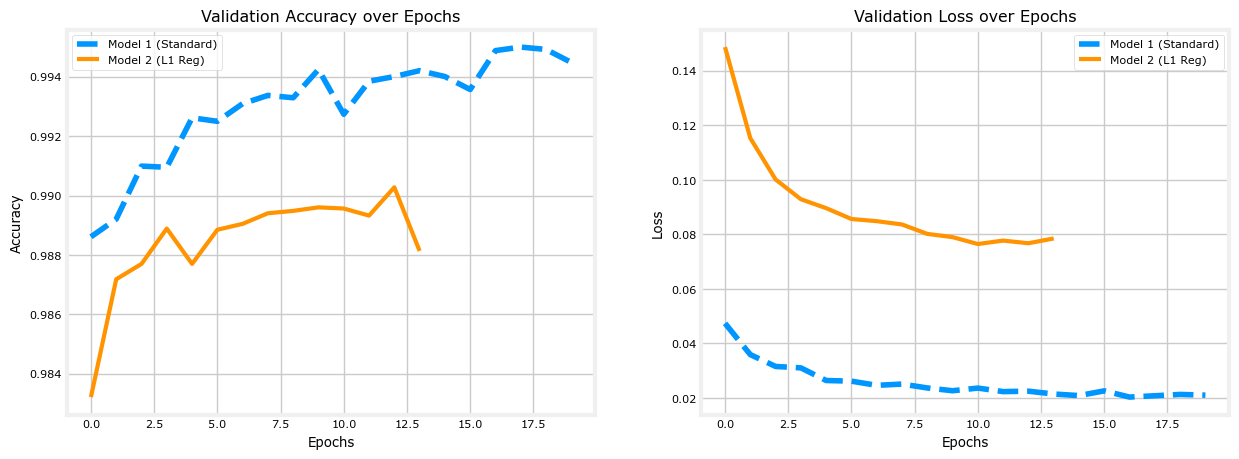

--- Final Project Results ---
          Metric Model 1 (Standard)  Model 2 (L1 Regularized)
0  Test Accuracy             71.01%                    71.06%
1  Features Used     All 41 (Dense)  All 41 (Sparse/Filtered)


In [52]:
# Create a figure with two subplots (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: Accuracy Comparison ---
ax1.plot(history_1.history['val_accuracy'], label='Model 1 (Standard)', linestyle='--')
ax1.plot(history_2.history['val_accuracy'], label='Model 2 (L1 Reg)', linewidth=3)
ax1.set_title('Validation Accuracy over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Loss Comparison ---
ax2.plot(history_1.history['val_loss'], label='Model 1 (Standard)', linestyle='--')
ax2.plot(history_2.history['val_loss'], label='Model 2 (L1 Reg)', linewidth=3)
ax2.set_title('Validation Loss over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

results_df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Features Used"],
    "Model 1 (Standard)": [f"{test_acc*100:.2f}%", "All 41 (Dense)"],
    "Model 2 (L1 Regularized)": [f"{acc_2*100:.2f}%", "All 41 (Sparse/Filtered)"]
})

print("--- Final Project Results ---")
print(results_df)